# Lección 2 — Optimización, gradientes y regularización

**Repositorio:** `deep-learning-complete-guide`  
**Objetivo:** entender cómo se entrenan los modelos de Deep Learning: qué función se optimiza, cómo se calcula el gradiente, cómo se actualizan los parámetros y cómo se controla el sobreajuste.

---

## Índice

1. Planteamiento del problema de optimización  
2. Funciones de pérdida  
3. Máxima verosimilitud y entropía cruzada  
4. Pérdidas basadas en el margen  
5. Gradientes y derivadas numéricas  
6. Descenso de gradiente  
7. SGD con mini-batches  
8. Momentum, Nesterov y Adam  
9. Backpropagation y grafos de cómputo  
10. Estimación del rendimiento: sesgo, varianza y ruido  
11. Regularización: L2, early stopping y data augmentation  
12. Ejercicios tipo examen resueltos

<div style="background:rgba(47,85,151,0.12);border-left:5px solid #2f5597;padding:14px;border-radius:8px;color:inherit">

### Cómo usar este notebook

Este notebook está pensado para estudiar y para publicarse en GitHub.

- Las explicaciones son cortas, pero cada concepto importante va acompañado de fórmulas y código.
- Las celdas de código usan datos sintéticos y son reproducibles.
- Los bloques visuales usan colores compatibles con modo claro y modo oscuro.
- En los ejercicios, lo importante no es memorizar la respuesta, sino reconocer el patrón de razonamiento.

</div>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, log_loss

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)
np.set_printoptions(precision=4, suppress=True)

---

# 1. Planteamiento del problema de optimización

En aprendizaje supervisado tenemos un conjunto de datos:

$$
D = \{(x_i, y_i)\}_{i=1}^{N}
$$

Un modelo con parámetros $\Phi$ produce una predicción:

$$
\hat{y}_i = f(x_i; \Phi)
$$

La función de pérdida mide el error en un solo ejemplo:

$$
L(\hat{y}_i, y_i)
$$

La función de coste o riesgo empírico mide el error medio sobre el conjunto de entrenamiento:

$$
J(\Phi) = \frac{1}{N}\sum_{i=1}^{N} L(f(x_i;\Phi), y_i)
$$

Entrenar consiste en encontrar los parámetros que minimizan esa función:

$$
\hat{\Phi} = \arg\min_{\Phi} J(\Phi)
$$

<div style="background:rgba(40,130,80,0.13);border-left:5px solid #2e7d32;padding:14px;border-radius:8px;color:inherit">

### Idea clave

En Deep Learning casi todo se reduce a este esquema:

1. Definir un modelo $f(x;\Phi)$.
2. Elegir una función de pérdida $L$ adecuada al problema.
3. Calcular el gradiente $
abla_\Phi J(\Phi)$.
4. Actualizar los parámetros en dirección contraria al gradiente.

</div>

## Entrenamiento frente a inferencia

| Fase | Qué se hace | Resultado |
|---|---|---|
| Entrenamiento | Se ajustan los parámetros $\Phi$ minimizando $J(\Phi)$ | Modelo entrenado |
| Inferencia | Se calcula $f(x;\Phi)$ con parámetros ya fijados | Predicción |

En inferencia **no se vuelven a estimar los parámetros**. Solo se usa el modelo ya entrenado.

---

# 2. Funciones de pérdida para regresión

En regresión la salida suele ser un número real. Las pérdidas más habituales son:

## MSE / L2

$$
L_{2}(y, \hat{y}) = (y - \hat{y})^2
$$

Penaliza mucho los errores grandes porque el error se eleva al cuadrado.

## MAE / L1

$$
L_{1}(y, \hat{y}) = |y - \hat{y}|
$$

Es más robusta a outliers porque crece linealmente.

## Huber

$$
L_{\delta}(y,\hat{y}) =
\begin{cases}
\frac{1}{2}(y-\hat{y})^2, & \text{si } |y-\hat{y}| < \delta \\
\delta\left(|y-\hat{y}| - \frac{\delta}{2}\right), & \text{si } |y-\hat{y}| \geq \delta
\end{cases}
$$

Combina lo mejor de MSE y MAE: se comporta como MSE cerca de cero y como MAE para errores grandes.

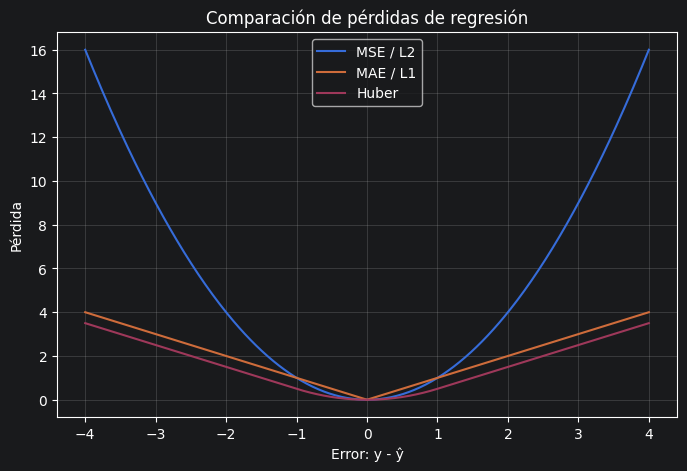

In [2]:
def mse_loss(error):
    return error**2

def mae_loss(error):
    return np.abs(error)

def huber_loss(error, delta=1.0):
    abs_error = np.abs(error)
    return np.where(
        abs_error < delta,
        0.5 * error**2,
        delta * (abs_error - 0.5 * delta)
    )

errors = np.linspace(-4, 4, 400)

plt.figure(figsize=(8, 5))
plt.plot(errors, mse_loss(errors), label="MSE / L2")
plt.plot(errors, mae_loss(errors), label="MAE / L1")
plt.plot(errors, huber_loss(errors, delta=1.0), label="Huber")
plt.xlabel("Error: y - ŷ")
plt.ylabel("Pérdida")
plt.title("Comparación de pérdidas de regresión")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

<div style="background:rgba(245,166,35,0.14);border-left:5px solid #b7791f;padding:14px;border-radius:8px;color:inherit">

### Interpretación para examen

- **MSE**: muy sensible a outliers.
- **MAE**: más robusta ante outliers.
- **Huber**: útil cuando se quieren penalizar bien los errores pequeños, pero sin disparar demasiado la pérdida ante valores atípicos.

</div>

---

# 3. Máxima verosimilitud y funciones de pérdida

Una manera formal de diseñar una pérdida es asumir que el modelo predice una distribución de probabilidad:

$$
Pr(y \mid x; \Phi)
$$

El criterio de máxima verosimilitud busca parámetros que asignen probabilidad alta a los datos observados:

$$
\hat{\Phi} = \arg\max_{\Phi} \prod_{i=1}^{N} Pr(y_i \mid x_i; \Phi)
$$

Como los productos de probabilidades pueden ser muy pequeños, se usa el logaritmo:

$$
\hat{\Phi} = \arg\max_{\Phi} \sum_{i=1}^{N} \log Pr(y_i \mid x_i; \Phi)
$$

Para convertirlo en un problema de minimización, se cambia el signo:

$$
J(\Phi) = -\sum_{i=1}^{N} \log Pr(y_i \mid x_i; \Phi)
$$

## 3.1 Regresión con ruido gaussiano conduce a MSE

Si asumimos:

$$
y_i \sim \mathcal{N}(\mu_i, \sigma^2)
$$

Y el modelo predice la media:

$$
\mu_i = f(x_i;\Phi)
$$

La minimización de la log-verosimilitud negativa termina siendo equivalente a minimizar:

$$
\sum_{i=1}^{N}(y_i - f(x_i;\Phi))^2
$$

Es decir, **MSE aparece de forma natural cuando asumimos ruido gaussiano**.

## 3.2 Clasificación binaria: sigmoid + Binary Cross-Entropy

En clasificación binaria:

$$
y \in \{0,1\}
$$

El modelo produce un valor real, llamado logit:

$$
z = f(x;\Phi)
$$

Para convertirlo en probabilidad se aplica la sigmoide:

$$
\hat{p} = \sigma(z)=\frac{1}{1+e^{-z}}
$$

La función de pérdida habitual es Binary Cross-Entropy:

$$
L(y, \hat{p}) = -\left[y\log(\hat{p}) + (1-y)\log(1-\hat{p})\right]
$$

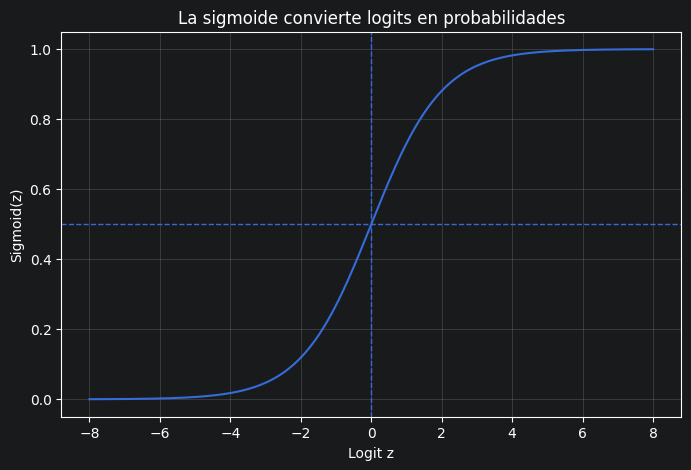

In [3]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def binary_cross_entropy(y_true, y_prob, eps=1e-12):
    y_prob = np.clip(y_prob, eps, 1 - eps)
    return -(y_true * np.log(y_prob) + (1 - y_true) * np.log(1 - y_prob))

z = np.linspace(-8, 8, 300)
p = sigmoid(z)

plt.figure(figsize=(8, 5))
plt.plot(z, p)
plt.axhline(0.5, linestyle="--", linewidth=1)
plt.axvline(0, linestyle="--", linewidth=1)
plt.xlabel("Logit z")
plt.ylabel("Sigmoid(z)")
plt.title("La sigmoide convierte logits en probabilidades")
plt.grid(True, alpha=0.3)
plt.show()

### Ejemplo manual: Binary Cross-Entropy

Supongamos un batch de 5 ejemplos:

$$
y = [1,0,0,1,0]
$$

$$
\hat{p} = [0.1,0.1,0.45,0.9,0.7]
$$

Calculamos la pérdida de cada muestra y luego la media.

In [4]:
y_true = np.array([1, 0, 0, 1, 0])
y_prob = np.array([0.1, 0.1, 0.45, 0.9, 0.7])

losses = binary_cross_entropy(y_true, y_prob)

bce_table = pd.DataFrame({
    "y": y_true,
    "ŷ": y_prob,
    "BCE": losses
})

print(bce_table)
print("\nPérdida media:", losses.mean())

   y     ŷ       BCE
0  1  0.10  2.302585
1  0  0.10  0.105361
2  0  0.45  0.597837
3  1  0.90  0.105361
4  0  0.70  1.203973

Pérdida media: 0.8630231858782509


## 3.3 Clasificación multiclase: softmax + categorical cross-entropy

En clasificación multiclase con $K$ clases, el modelo produce $K$ logits:

$$
z = [z_1,z_2,\dots,z_K]
$$

Softmax los convierte en probabilidades que suman 1:

$$
\text{softmax}(z_k)=\frac{e^{z_k}}{\sum_{j=1}^{K}e^{z_j}}
$$

La pérdida para una etiqueta one-hot $y$ es:

$$
L(y,\hat{p})=-\sum_{k=1}^{K} y_k\log(\hat{p}_k)
$$

Si la clase correcta es $c$, esto equivale a:

$$
L=-\log(\hat{p}_c)
$$

In [5]:
def softmax(logits):
    logits = logits - np.max(logits, axis=-1, keepdims=True)
    exp_logits = np.exp(logits)
    return exp_logits / np.sum(exp_logits, axis=-1, keepdims=True)

logits = np.array([[2.0, 1.0, 0.1]])
y_onehot = np.array([[1, 0, 0]])
probs = softmax(logits)
ce = -np.sum(y_onehot * np.log(probs))

print("Logits:", logits)
print("Probabilidades softmax:", probs)
print("Categorical cross-entropy:", ce)

Logits: [[2.  1.  0.1]]
Probabilidades softmax: [[0.659  0.2424 0.0986]]
Categorical cross-entropy: 0.4170300162778335


<div style="background:rgba(47,85,151,0.12);border-left:5px solid #2f5597;padding:14px;border-radius:8px;color:inherit">

### Dos salidas en clasificación binaria

Si una red tiene **dos salidas**, una por clase, se suele usar:

$$
	ext{Softmax} + 	ext{Multiclass Cross-Entropy}
$$

Si una red tiene **una salida**, se suele usar:

$$
	ext{Sigmoid} + 	ext{Binary Cross-Entropy}
$$

</div>

---

# 4. Pérdidas basadas en el margen

En clasificación binaria con etiquetas:

$$
y \in \{-1,1\}
$$

El margen se define como:

$$
m = y \cdot f(x;\Phi)
$$

Interpretación:

- Si $m > 0$, el modelo clasifica correctamente.
- Si $m < 0$, el modelo se equivoca.
- Cuanto mayor sea $m$, más segura es la clasificación.

Pérdidas habituales:

$$
L_{0/1}=\mathbb{I}(m < 0)
$$

$$
L_{exp}=e^{-m}
$$

$$
L_{hinge}=\max(0,1-m)
$$

$$
L_{logistic}=\log(1+e^{-2m})
$$

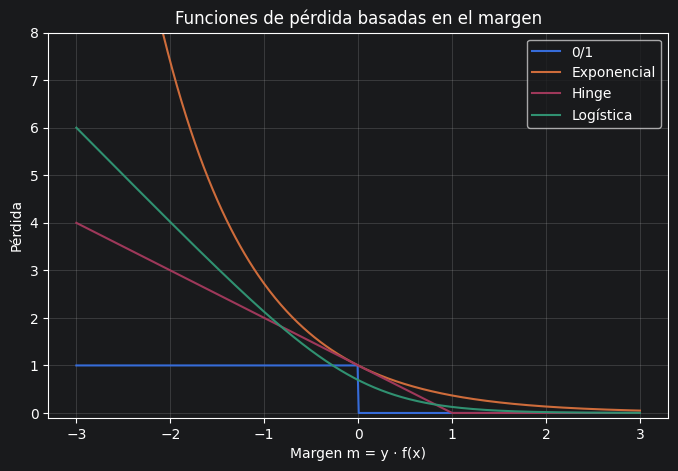

In [6]:
def zero_one_margin(m):
    return (m < 0).astype(float)

def exponential_margin(m):
    return np.exp(-m)

def hinge_margin(m):
    return np.maximum(0, 1 - m)

def logistic_margin(m):
    return np.log1p(np.exp(-2 * m))

m = np.linspace(-3, 3, 500)

plt.figure(figsize=(8, 5))
plt.plot(m, zero_one_margin(m), label="0/1")
plt.plot(m, exponential_margin(m), label="Exponencial")
plt.plot(m, hinge_margin(m), label="Hinge")
plt.plot(m, logistic_margin(m), label="Logística")
plt.ylim(-0.1, 8)
plt.xlabel("Margen m = y · f(x)")
plt.ylabel("Pérdida")
plt.title("Funciones de pérdida basadas en el margen")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Ejemplo manual: pérdida exponencial

$$
L(y, f(x)) = e^{-y f(x)}
$$

Si el producto $y f(x)$ es negativo, el modelo se equivoca y la pérdida crece mucho.

In [7]:
y = np.array([1, -1, -1, 1, -1])
f = np.array([-2, -2, -0.4, 4, 2])
exp_losses = np.exp(-y * f)

pd.DataFrame({
    "y": y,
    "f(x)": f,
    "margen y·f(x)": y * f,
    "exp(-y·f(x))": exp_losses,
})

,y,f(x),margen y·f(x),exp(-y·f(x))
0,1,-2.0,-2.0,7.389056
1,-1,-2.0,2.0,0.135335
2,-1,-0.4,0.4,0.670320
3,1,4.0,4.0,0.018316
4,-1,2.0,-2.0,7.389056


In [8]:
print("Pérdida media exponencial:", exp_losses.mean())

Pérdida media exponencial: 3.1204166332044574


---

# 5. Gradientes y derivadas numéricas

Para minimizar $J(\Phi)$ necesitamos saber cómo cambia $J$ ante pequeños cambios en los parámetros.

En una dimensión:

$$
\frac{df(x)}{dx}=\lim_{h\to 0}\frac{f(x+h)-f(x)}{h}
$$

Una aproximación numérica más estable es la diferencia centrada:

$$
\frac{df(x)}{dx}\approx \frac{f(x+h)-f(x-h)}{2h}
$$

En varias dimensiones, el gradiente es el vector de derivadas parciales:

$$
\nabla_{\Phi}J(\Phi)=
\begin{bmatrix}
\frac{\partial J}{\partial \Phi_0}\\
\frac{\partial J}{\partial \Phi_1}\\
\vdots
\end{bmatrix}
$$

In [9]:
def f_1d(x):
    return x**2 - 4*x + 5

def df_1d_analytical(x):
    return 2*x - 4

def numerical_derivative(f, x, h=1e-5):
    return (f(x + h) - f(x - h)) / (2*h)

x0 = 3.0
print("Derivada analítica:", df_1d_analytical(x0))
print("Derivada numérica:", numerical_derivative(f_1d, x0))

Derivada analítica: 2.0
Derivada numérica: 2.0000000000131024


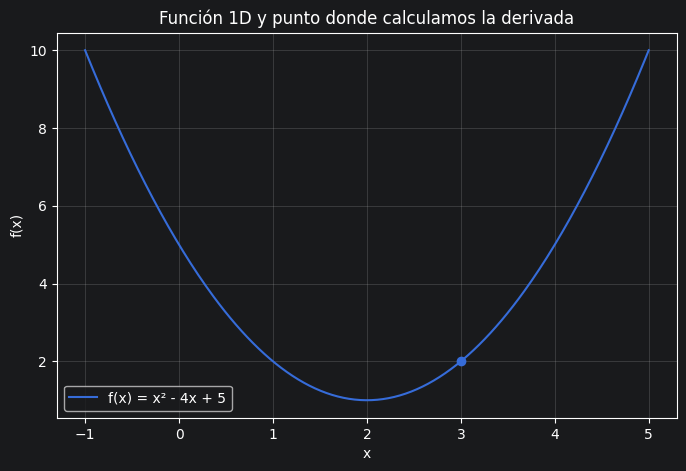

In [10]:
xs = np.linspace(-1, 5, 300)

plt.figure(figsize=(8, 5))
plt.plot(xs, f_1d(xs), label="f(x) = x² - 4x + 5")
plt.scatter([x0], [f_1d(x0)], zorder=3)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Función 1D y punto donde calculamos la derivada")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

<div style="background:rgba(245,166,35,0.14);border-left:5px solid #b7791f;padding:14px;border-radius:8px;color:inherit">

### Para qué sirve la derivada numérica

En Deep Learning no se usa para entrenar redes grandes porque sería demasiado lento. Sin embargo, es muy útil para comprobar si una derivada analítica o una implementación de backpropagation está bien calculada.

</div>

---

# 6. Descenso de gradiente

El gradiente apunta hacia la dirección de máximo incremento de la función de coste. Para minimizar, nos movemos en la dirección contraria:

$$
\Phi_{t+1} = \Phi_t - \alpha \nabla_{\Phi}J(\Phi_t)
$$

Donde:

- $\Phi_t$ son los parámetros en la iteración actual.
- $\alpha$ es el learning rate.
- $\nabla_{\Phi}J(\Phi_t)$ es el gradiente de la función de coste.

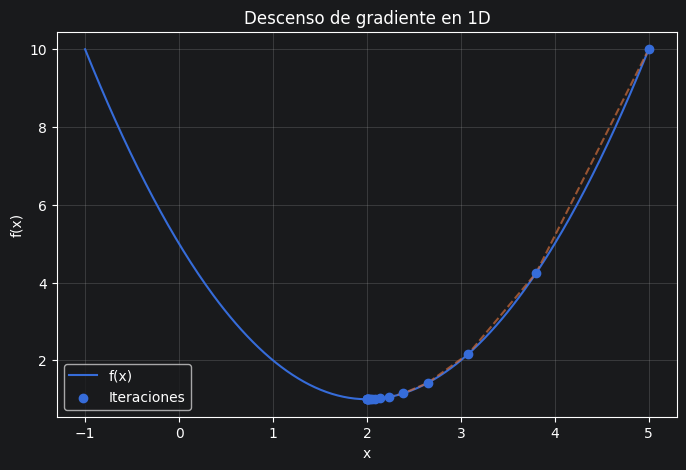

Último valor de x: 2.0014105549537278


In [11]:
def gradient_descent_1d(grad, x_init, lr=0.1, n_steps=20):
    x = x_init
    history = [x]
    for _ in range(n_steps):
        x = x - lr * grad(x)
        history.append(x)
    return np.array(history)

history = gradient_descent_1d(df_1d_analytical, x_init=5.0, lr=0.2, n_steps=15)

plt.figure(figsize=(8, 5))
plt.plot(xs, f_1d(xs), label="f(x)")
plt.scatter(history, f_1d(history), zorder=3, label="Iteraciones")
plt.plot(history, f_1d(history), linestyle="--", alpha=0.7)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Descenso de gradiente en 1D")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("Último valor de x:", history[-1])

<div style="background:rgba(190,45,45,0.12);border-left:5px solid #b83232;padding:14px;border-radius:8px;color:inherit">

### Errores típicos con el learning rate

- Si $lpha$ es demasiado pequeño, el entrenamiento avanza muy lento.
- Si $lpha$ es demasiado grande, el entrenamiento puede oscilar o divergir.
- En SGD, una pérdida muy errática puede suavizarse bajando el learning rate o aumentando el tamaño del batch.

</div>

## 6.1 Ejemplo completo: regresión lineal entrenada con descenso de gradiente

Modelo:

$$
\hat{y}=w_0+w_1x
$$

Pérdida media:

$$
J(w)=\frac{1}{N}\sum_{i=1}^{N}(\hat{y}_i-y_i)^2
$$

Gradientes:

$$
\frac{\partial J}{\partial w_0}=\frac{2}{N}\sum_{i=1}^{N}(\hat{y}_i-y_i)
$$

$$
\frac{\partial J}{\partial w_1}=\frac{2}{N}\sum_{i=1}^{N}(\hat{y}_i-y_i)x_i
$$

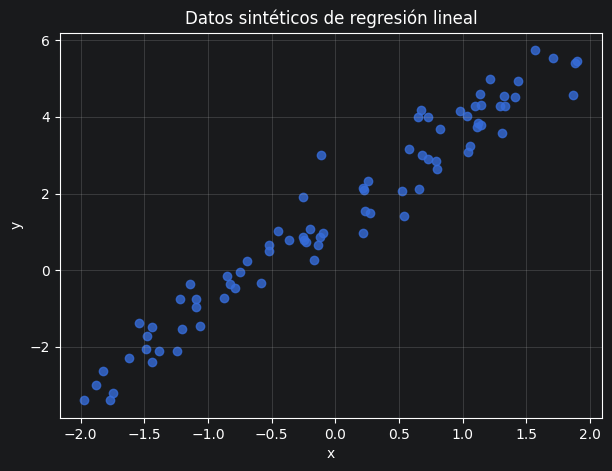

In [12]:
# Datos sintéticos
n_samples = 80
X = rng.uniform(-2, 2, size=(n_samples, 1))
y = 1.5 + 2.2 * X[:, 0] + rng.normal(0, 0.6, size=n_samples)

plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], y, alpha=0.8)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Datos sintéticos de regresión lineal")
plt.grid(True, alpha=0.3)
plt.show()

In [13]:
def linear_model(X, w):
    return w[0] + w[1] * X[:, 0]

def mse_cost(X, y, w):
    y_hat = linear_model(X, w)
    return np.mean((y_hat - y)**2)

def mse_gradient_linear(X, y, w):
    y_hat = linear_model(X, w)
    error = y_hat - y
    grad_w0 = 2 * np.mean(error)
    grad_w1 = 2 * np.mean(error * X[:, 0])
    return np.array([grad_w0, grad_w1])

def train_gradient_descent(X, y, lr=0.05, n_steps=100):
    w = np.array([0.0, 0.0])
    history = []
    for step in range(n_steps):
        cost = mse_cost(X, y, w)
        history.append((step, w[0], w[1], cost))
        grad = mse_gradient_linear(X, y, w)
        w = w - lr * grad
    return w, pd.DataFrame(history, columns=["step", "w0", "w1", "cost"])

w_gd, hist_gd = train_gradient_descent(X, y, lr=0.05, n_steps=120)
print("Parámetros aprendidos:", w_gd)
hist_gd.tail()

Parámetros aprendidos: [1.4242 2.2698]


,step,w0,w1,cost
115,115,1.424230,2.269816,0.30749
116,116,1.424231,2.269816,0.30749
117,117,1.424231,2.269816,0.30749
118,118,1.424232,2.269816,0.30749
119,119,1.424232,2.269816,0.30749


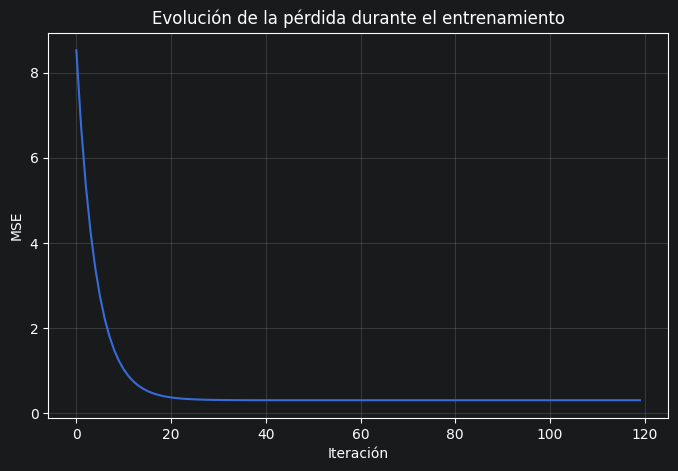

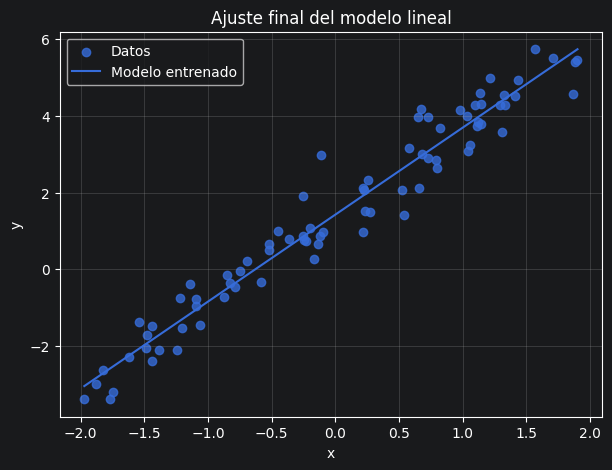

In [14]:
plt.figure(figsize=(8, 5))
plt.plot(hist_gd["step"], hist_gd["cost"])
plt.xlabel("Iteración")
plt.ylabel("MSE")
plt.title("Evolución de la pérdida durante el entrenamiento")
plt.grid(True, alpha=0.3)
plt.show()

x_line = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)
y_line = w_gd[0] + w_gd[1] * x_line

plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], y, alpha=0.8, label="Datos")
plt.plot(x_line, y_line, label="Modelo entrenado")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Ajuste final del modelo lineal")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

---

# 7. Line Search

En descenso de gradiente se puede usar un learning rate fijo, pero también se puede buscar un tamaño de paso adecuado en cada iteración.

La idea de **line search** es probar valores de $\alpha$ en la dirección de descenso y quedarse con el que más reduce la función de coste.

En Deep Learning moderno se suele usar un learning rate fijo o planificado, pero line search ayuda a entender el papel del tamaño del paso.

In [15]:
def line_search_step(x, grad_fn, loss_fn, candidate_lrs):
    grad = grad_fn(x)
    candidates = []
    for lr in candidate_lrs:
        x_new = x - lr * grad
        candidates.append((lr, x_new, loss_fn(x_new)))
    return min(candidates, key=lambda t: t[2])

candidate_lrs = np.array([0.001, 0.01, 0.05, 0.1, 0.2, 0.4])
x_current = 5.0
best_lr, x_new, best_loss = line_search_step(x_current, df_1d_analytical, f_1d, candidate_lrs)

print("x actual:", x_current)
print("Mejor learning rate:", best_lr)
print("x nuevo:", x_new)
print("Nueva pérdida:", best_loss)

x actual: 5.0
Mejor learning rate: 0.4
x nuevo: 2.5999999999999996
Nueva pérdida: 1.3599999999999994


---

# 8. Descenso de Gradiente Estocástico con mini-batches

En full-batch gradient descent se usa todo el conjunto de entrenamiento para calcular cada actualización:

$$
\nabla J(\Phi)=\frac{1}{N}\sum_{i=1}^{N}\nabla L_i(\Phi)
$$

En SGD con mini-batches se usa solo un subconjunto $B_t$:

$$
\nabla J_{B_t}(\Phi)=\frac{1}{|B_t|}\sum_{i\in B_t}\nabla L_i(\Phi)
$$

Actualización:

$$
\Phi_{t+1}=\Phi_t-\alpha\nabla J_{B_t}(\Phi_t)
$$

Una época termina cuando el algoritmo ha usado todos los datos de entrenamiento una vez.

<div style="background:rgba(47,85,151,0.12);border-left:5px solid #2f5597;padding:14px;border-radius:8px;color:inherit">

### Número de iteraciones por época

Si hay $N$ ejemplos y batch size $B$:

$$
	ext{iteraciones por época} = \left\lceil \frac{N}{B} ightceil
$$

Ejemplo: con $N=1000$ y $B=64$:

$$
\left\lceil \frac{1000}{64} \ightceil = 16
$$

</div>

In [16]:
def minibatch_indices(n_samples, batch_size, rng):
    indices = rng.permutation(n_samples)
    for start in range(0, n_samples, batch_size):
        yield indices[start:start + batch_size]

def train_sgd(X, y, lr=0.05, batch_size=16, n_epochs=20):
    w = np.array([0.0, 0.0])
    history = []
    step = 0
    for epoch in range(n_epochs):
        for batch_idx in minibatch_indices(len(y), batch_size, rng):
            X_batch = X[batch_idx]
            y_batch = y[batch_idx]
            grad = mse_gradient_linear(X_batch, y_batch, w)
            w = w - lr * grad
            history.append((epoch, step, w[0], w[1], mse_cost(X, y, w)))
            step += 1
    return w, pd.DataFrame(history, columns=["epoch", "step", "w0", "w1", "cost"])

w_sgd, hist_sgd = train_sgd(X, y, lr=0.05, batch_size=16, n_epochs=20)
print("Parámetros aprendidos con SGD:", w_sgd)
print("Iteraciones totales:", len(hist_sgd))
hist_sgd.tail()

Parámetros aprendidos con SGD: [1.4264 2.2709]
Iteraciones totales: 100


,epoch,step,w0,w1,cost
95,19,95,1.411470,2.282914,0.307844
96,19,96,1.408473,2.287285,0.308080
97,19,97,1.417597,2.283025,0.307733
98,19,98,1.434283,2.274662,0.307620
99,19,99,1.426368,2.270932,0.307496


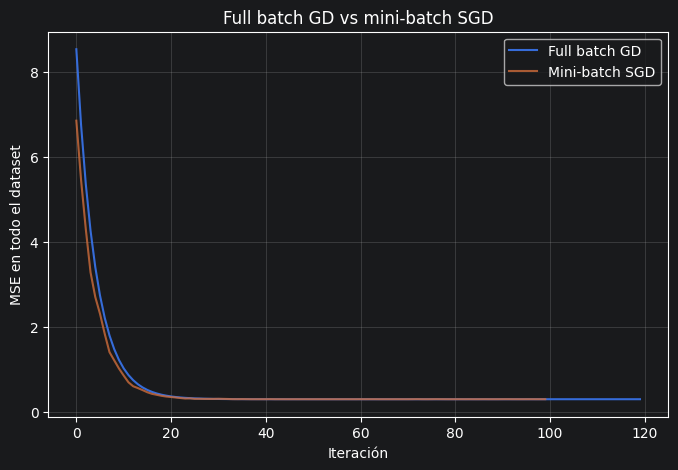

In [17]:
plt.figure(figsize=(8, 5))
plt.plot(hist_gd["step"], hist_gd["cost"], label="Full batch GD")
plt.plot(hist_sgd["step"], hist_sgd["cost"], label="Mini-batch SGD", alpha=0.8)
plt.xlabel("Iteración")
plt.ylabel("MSE en todo el dataset")
plt.title("Full batch GD vs mini-batch SGD")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

<div style="background:rgba(245,166,35,0.14);border-left:5px solid #b7791f;padding:14px;border-radius:8px;color:inherit">

### Propiedades de SGD

- Es más barato por iteración que full-batch gradient descent.
- Introduce ruido en las actualizaciones.
- Ese ruido puede ayudar a escapar de zonas poco favorables.
- No converge de forma tan suave como full-batch.
- En la práctica se barajan los datos al inicio de cada época y se recorren mini-batches secuencialmente.

</div>

---

# 9. Momentum, Nesterov y Adam

## Momentum

Momentum acumula una media móvil de gradientes:

$$
m_{t+1}=\beta m_t + (1-\beta)g_t
$$

Y actualiza:

$$
\Phi_{t+1}=\Phi_t-\alpha m_{t+1}
$$

Intuición:

- Si los gradientes apuntan en direcciones parecidas, el movimiento se acelera.
- Si el gradiente oscila mucho, las componentes se cancelan parcialmente.
- La trayectoria suele ser más suave.

In [18]:
beta = 0.8
alpha = 0.001
m_t = np.array([0.33, -1.35])
g_t = np.array([-0.1, 2.34])
w_t = np.array([3.4, -1.6])

m_next = beta * m_t + (1 - beta) * g_t
w_next = w_t - alpha * m_next

print("m_{t+1} =", m_next)
print("w_{t+1} =", w_next)

m_{t+1} = [ 0.244 -0.612]
w_{t+1} = [ 3.3998 -1.5994]


## Nesterov Momentum

Nesterov modifica el punto donde se mide el gradiente. Primero se mueve en la dirección estimada por el momentum y después mide el gradiente:

$$
g_t = \nabla J(\Phi_t - \alpha m_t)
$$

La intuición es que el algoritmo mira un poco hacia delante antes de corregir la dirección.

## Adam

Adam combina dos ideas:

1. Momentum sobre el gradiente.
2. Learning rates adaptativos por parámetro usando el cuadrado del gradiente.

Esquema simplificado:

$$
m_t = \beta_1 m_{t-1} + (1-\beta_1)g_t
$$

$$
v_t = \beta_2 v_{t-1} + (1-\beta_2)g_t^2
$$

$$
\Phi_t = \Phi_{t-1} - \alpha \frac{\hat{m}_t}{\sqrt{\hat{v}_t}+\epsilon}
$$

In [19]:
def adam_optimize_1d(grad_fn, x_init=5.0, lr=0.1, beta1=0.9, beta2=0.999, eps=1e-8, steps=40):
    x = x_init
    m = 0.0
    v = 0.0
    history = []
    for t in range(1, steps + 1):
        g = grad_fn(x)
        m = beta1 * m + (1 - beta1) * g
        v = beta2 * v + (1 - beta2) * (g**2)
        m_hat = m / (1 - beta1**t)
        v_hat = v / (1 - beta2**t)
        x = x - lr * m_hat / (np.sqrt(v_hat) + eps)
        history.append((t, x, f_1d(x)))
    return pd.DataFrame(history, columns=["step", "x", "loss"])

adam_hist = adam_optimize_1d(df_1d_analytical, x_init=5.0, lr=0.2, steps=50)
adam_hist.tail()

,step,x,loss
45,46,2.083582,1.006986
46,47,2.107137,1.011478
47,48,2.126515,1.016006
48,49,2.141702,1.020079
49,50,2.152760,1.023336


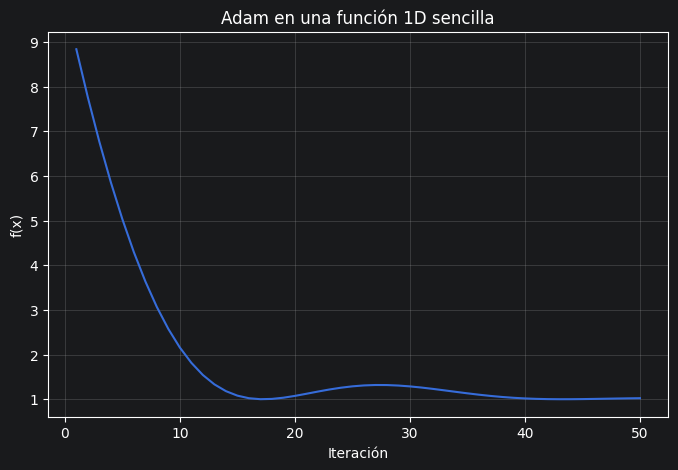

In [20]:
plt.figure(figsize=(8, 5))
plt.plot(adam_hist["step"], adam_hist["loss"])
plt.xlabel("Iteración")
plt.ylabel("f(x)")
plt.title("Adam en una función 1D sencilla")
plt.grid(True, alpha=0.3)
plt.show()

<div style="background:rgba(40,130,80,0.13);border-left:5px solid #2e7d32;padding:14px;border-radius:8px;color:inherit">

### Cuándo usar cada optimizador

| Optimizador | Idea | Uso típico |
|---|---|---|
| GD full-batch | Gradiente con todos los datos | Didáctico, datasets pequeños |
| SGD mini-batch | Gradiente con subconjuntos | Base del entrenamiento moderno |
| Momentum | Suaviza y acelera SGD | Valles con oscilaciones |
| Adam | Momentum + escala adaptativa | Muy usado por defecto en Deep Learning |

</div>

---

# 10. Backpropagation y grafos de cómputo

Backpropagation aplica la regla de la cadena sobre un grafo de cómputo.

La idea central es:

1. **Forward:** calcular todos los valores intermedios.
2. **Backward:** recorrer el grafo desde la salida hacia las entradas, propagando derivadas.

Ejemplo:

$$
J(a,b,c)=(a+2b)c
$$

Definimos nodos intermedios:

$$
h = 2b
$$

$$
g = a+h
$$

$$
J = g c
$$

In [21]:
def forward_graph(a, b, c):
    h = 2 * b
    g = a + h
    J = g * c
    return {"a": a, "b": b, "c": c, "h": h, "g": g, "J": J}

def backward_graph(values):
    # J = g*c
    dJ_dJ = 1.0
    dJ_dg = values["c"] * dJ_dJ
    dJ_dc = values["g"] * dJ_dJ
    
    # g = a+h
    dJ_da = 1.0 * dJ_dg
    dJ_dh = 1.0 * dJ_dg
    
    # h = 2b
    dJ_db = 2.0 * dJ_dh
    
    return {"dJ/da": dJ_da, "dJ/db": dJ_db, "dJ/dc": dJ_dc}

values = forward_graph(a=3, b=1, c=-2)
grads = backward_graph(values)

print("Forward:", values)
print("Backward:", grads)

Forward: {'a': 3, 'b': 1, 'c': -2, 'h': 2, 'g': 5, 'J': -10}
Backward: {'dJ/da': -2.0, 'dJ/db': -4.0, 'dJ/dc': 5.0}


## Ramificaciones: los gradientes se suman

Si una variable afecta a la salida por varios caminos, el gradiente total es la suma de todos esos caminos.

Ejemplo:

$$
J(a,b)=(a+b)(b+1)
$$

Definimos:

$$
g=a+b, \quad h=b+1, \quad J=gh
$$

Para $b$, hay dos caminos:

1. $b \rightarrow g \rightarrow J$
2. $b \rightarrow h \rightarrow J$

Por eso:

$$
\frac{\partial J}{\partial b}=\frac{\partial J}{\partial g}\frac{\partial g}{\partial b}+\frac{\partial J}{\partial h}\frac{\partial h}{\partial b}
$$

In [22]:
def forward_branch(a, b):
    g = a + b
    h = b + 1
    J = g * h
    return {"a": a, "b": b, "g": g, "h": h, "J": J}

def backward_branch(values):
    # J = g*h
    dJ_dg = values["h"]
    dJ_dh = values["g"]
    
    # g = a+b, h=b+1
    dJ_da = dJ_dg * 1
    dJ_db = dJ_dg * 1 + dJ_dh * 1
    return {"dJ/da": dJ_da, "dJ/db": dJ_db}

values = forward_branch(a=-3, b=2)
grads = backward_branch(values)

print("Forward:", values)
print("Backward:", grads)
print("Comprobación analítica dJ/db = a + 2b + 1 =", -3 + 2*2 + 1)

Forward: {'a': -3, 'b': 2, 'g': -1, 'h': 3, 'J': -3}
Backward: {'dJ/da': 3, 'dJ/db': 2}
Comprobación analítica dJ/db = a + 2b + 1 = 2


## Backpropagation en un modelo lineal

Modelo:

$$
\hat{y}=\phi^T x
$$

Pérdida:

$$
L=(\phi^T x-y)^2
$$

Sea:

$$
g=\phi^T x-y
$$

Entonces:

$$
L=g^2
$$

Gradientes:

$$
\frac{\partial L}{\partial g}=2g
$$

$$
\frac{\partial g}{\partial \phi}=x
$$

Por regla de la cadena:

$$
\frac{\partial L}{\partial \phi}=2g x
$$

In [23]:
x_vec = np.array([-1, 1])
phi = np.array([2, 5])
y_scalar = 1

g = phi @ x_vec - y_scalar
L = g**2
grad_phi = 2 * g * x_vec

def loss_phi(phi):
    return (phi @ x_vec - y_scalar)**2

def numerical_gradient_vector(f, theta, h=1e-5):
    grad = np.zeros_like(theta, dtype=float)
    for j in range(len(theta)):
        theta_plus = theta.copy().astype(float)
        theta_minus = theta.copy().astype(float)
        theta_plus[j] += h
        theta_minus[j] -= h
        grad[j] = (f(theta_plus) - f(theta_minus)) / (2*h)
    return grad

print("g:", g)
print("L:", L)
print("Gradiente analítico:", grad_phi)
print("Gradiente numérico:", numerical_gradient_vector(loss_phi, phi.astype(float)))

g: 2
L: 4
Gradiente analítico: [-4  4]
Gradiente numérico: [-4.  4.]


---

# 11. Estimación del rendimiento: ruido, sesgo y varianza

El error de generalización puede entenderse mediante tres términos:

| Término | Significado |
|---|---|
| Ruido | Incertidumbre inevitable de los datos |
| Sesgo | Error por usar una familia de modelos demasiado limitada |
| Varianza | Sensibilidad del modelo al conjunto de entrenamiento concreto |

En regresión con MSE se suele expresar la idea como:

$$
\text{Error} \approx \text{Ruido} + \text{Sesgo}^2 + \text{Varianza}
$$

- **Underfitting:** mucho sesgo.
- **Overfitting:** mucha varianza.

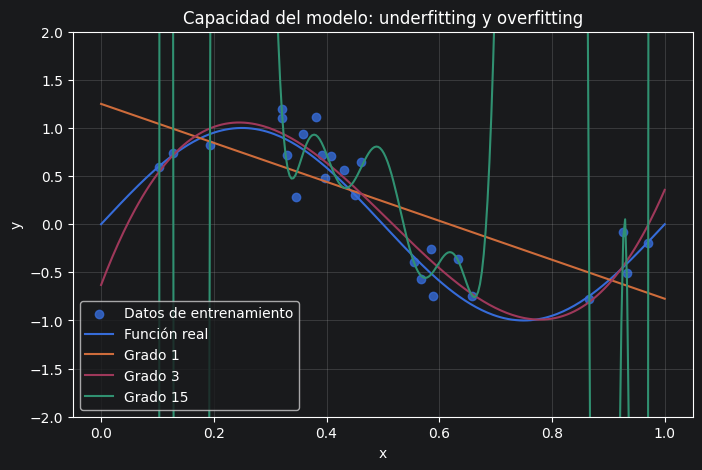

In [24]:
def true_function(x):
    return np.sin(2 * np.pi * x)

def make_regression_sample(n=20, noise=0.25, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    x = rng.uniform(0, 1, size=n)
    y = true_function(x) + rng.normal(0, noise, size=n)
    return x.reshape(-1, 1), y

X_train, y_train = make_regression_sample(n=25, noise=0.25, rng=rng)
x_grid = np.linspace(0, 1, 300).reshape(-1, 1)

models = {
    "Grado 1": make_pipeline(PolynomialFeatures(1), LinearRegression()),
    "Grado 3": make_pipeline(PolynomialFeatures(3), LinearRegression()),
    "Grado 15": make_pipeline(PolynomialFeatures(15), LinearRegression()),
}

plt.figure(figsize=(8, 5))
plt.scatter(X_train[:, 0], y_train, label="Datos de entrenamiento", alpha=0.8)
plt.plot(x_grid[:, 0], true_function(x_grid[:, 0]), label="Función real")
for name, model in models.items():
    model.fit(X_train, y_train)
    plt.plot(x_grid[:, 0], model.predict(x_grid), label=name)
plt.ylim(-2, 2)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Capacidad del modelo: underfitting y overfitting")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

<div style="background:rgba(47,85,151,0.12);border-left:5px solid #2f5597;padding:14px;border-radius:8px;color:inherit">

### Lectura de la figura

- Grado 1: modelo demasiado simple, alto sesgo.
- Grado 3: compromiso razonable.
- Grado 15: mucha flexibilidad, puede ajustarse al ruido, alta varianza.

</div>

## Validación, test e hiperparámetros

La separación correcta de datos es:

| Conjunto | Uso |
|---|---|
| Train | Ajustar parámetros del modelo |
| Validation | Elegir hiperparámetros, arquitectura, regularización, learning rate, etc. |
| Test | Reportar rendimiento final una sola vez |

No se debe elegir el mejor modelo mirando el test, porque entonces el test deja de ser una estimación limpia de generalización.

In [25]:
# Ejemplo de hold-out train/validation/test
X_all, y_all = make_regression_sample(n=300, noise=0.25, rng=rng)
X_train, X_temp, y_train, y_temp = train_test_split(X_all, y_all, test_size=0.4, random_state=RANDOM_STATE)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=RANDOM_STATE)

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (180, 1) (180,)
Validation: (60, 1) (60,)
Test: (60, 1) (60,)


---

# 12. Regularización

La regularización busca reducir el error de generalización.

En sentido estricto, regularizar suele significar añadir un término a la función de coste:

$$
\hat{\Phi}=\arg\min_\Phi\left[\sum_{i=1}^{N}L(f(x_i;\Phi),y_i)+\lambda g(\Phi)\right]
$$

Donde:

- $g(\Phi)$ penaliza ciertos valores de los parámetros.
- $\lambda$ controla la fuerza de la regularización.

## Regularización L2 / Weight Decay

$$
J_{reg}(\Phi)=J(\Phi)+\lambda \sum_j \Phi_j^2
$$

En redes neuronales se suele aplicar a los pesos, no al sesgo, y se llama **weight decay**.

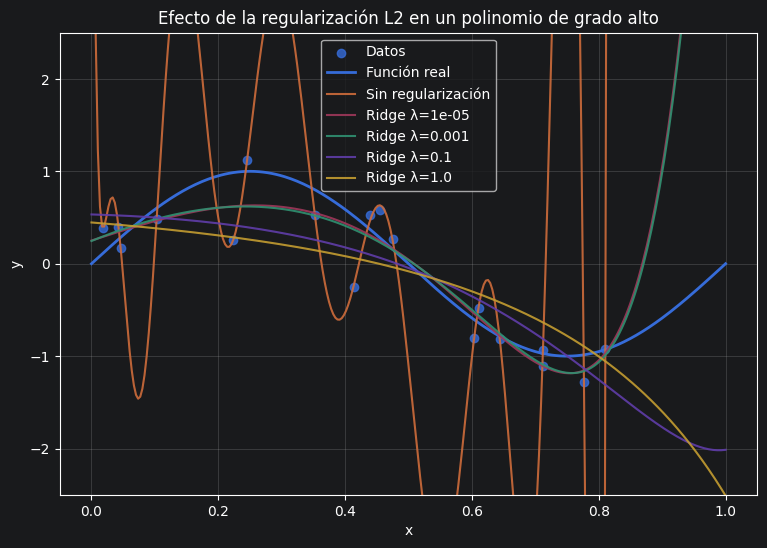

In [26]:
X_train_small, y_train_small = make_regression_sample(n=18, noise=0.25, rng=rng)

lambdas = [0.0, 1e-5, 1e-3, 1e-1, 1.0]
plt.figure(figsize=(9, 6))
plt.scatter(X_train_small[:, 0], y_train_small, label="Datos", alpha=0.8)
plt.plot(x_grid[:, 0], true_function(x_grid[:, 0]), label="Función real", linewidth=2)

for lam in lambdas:
    if lam == 0.0:
        model = make_pipeline(PolynomialFeatures(15), LinearRegression())
        label = "Sin regularización"
    else:
        model = make_pipeline(PolynomialFeatures(15), Ridge(alpha=lam))
        label = f"Ridge λ={lam}"
    model.fit(X_train_small, y_train_small)
    plt.plot(x_grid[:, 0], model.predict(x_grid), label=label, alpha=0.9)

plt.ylim(-2.5, 2.5)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Efecto de la regularización L2 en un polinomio de grado alto")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

<div style="background:rgba(40,130,80,0.13);border-left:5px solid #2e7d32;padding:14px;border-radius:8px;color:inherit">

### Qué consigue L2

- Penaliza pesos grandes.
- Favorece soluciones más suaves.
- Reduce la varianza.
- Puede aumentar el sesgo si $\lambda$ es demasiado grande.

</div>

## Regularización implícita

Algunos aspectos del propio entrenamiento también afectan a la generalización, aunque no aparezcan como un término explícito en la función de coste:

- learning rate;
- tamaño del batch;
- inicialización;
- optimizador;
- ruido introducido por SGD.

Por ejemplo, mini-batches pequeños introducen más ruido en el gradiente. Ese ruido puede ayudar a evitar soluciones demasiado ajustadas a peculiaridades concretas del entrenamiento.

## Early stopping

Early stopping consiste en parar el entrenamiento cuando la pérdida de validación deja de mejorar.

Interpretación:

- Si entrenamos demasiado, el modelo puede empezar a memorizar ruido.
- Parar antes reduce la complejidad efectiva del modelo.
- Tiene un efecto parecido a una regularización.

Pseudocódigo:

```python
best_val_loss = infinity
patience_counter = 0

for epoch in range(max_epochs):
    train_one_epoch(model, train_loader)
    val_loss = evaluate(model, val_loader)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        save_model(model)
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= patience:
        break
```

## Data augmentation

Data augmentation genera variaciones de los datos de entrenamiento que preservan la etiqueta.

Ejemplos en imágenes:

- giros pequeños;
- recortes;
- cambios de brillo;
- flips horizontales si tienen sentido;
- ruido;
- cambios de escala.

La idea es aumentar la diversidad efectiva del conjunto de entrenamiento y reducir la varianza.

---

# 13. Ejercicios tipo examen resueltos

Esta sección resume patrones de ejercicios del Tema 2. El objetivo es practicar el razonamiento típico del examen.

## 13.1 Test: funciones de pérdida

### Ejercicio: BCE en un batch

Datos:

$$
y=[1,0,0,1,0]
$$

$$
\hat{p}=[0.1,0.1,0.45,0.9,0.7]
$$

Pérdida:

$$
L(y,\hat{p})=-[y\log(\hat{p})+(1-y)\log(1-\hat{p})]
$$

In [27]:
y = np.array([1, 0, 0, 1, 0])
yhat = np.array([0.1, 0.1, 0.45, 0.9, 0.7])
loss_each = binary_cross_entropy(y, yhat)

result = pd.DataFrame({"y": y, "ŷ": yhat, "BCE": loss_each})
print(result)
print("Media:", loss_each.mean())

   y     ŷ       BCE
0  1  0.10  2.302585
1  0  0.10  0.105361
2  0  0.45  0.597837
3  1  0.90  0.105361
4  0  0.70  1.203973
Media: 0.8630231858782509


La respuesta aproximada es **0.86**.

### Ejercicio: pérdida exponencial

Datos:

$$
y=[1,-1,-1,1,-1]
$$

$$
f(x)=[-2,-2,-0.4,4,2]
$$

Pérdida:

$$
L=e^{-y f(x)}
$$

In [28]:
y = np.array([1, -1, -1, 1, -1])
f = np.array([-2, -2, -0.4, 4, 2])
loss_each = np.exp(-y * f)

result = pd.DataFrame({"y": y, "f(x)": f, "margen": y*f, "L_exp": loss_each})
print(result)
print("Media:", loss_each.mean())

   y  f(x)  margen     L_exp
0  1  -2.0    -2.0  7.389056
1 -1  -2.0     2.0  0.135335
2 -1  -0.4     0.4  0.670320
3  1   4.0     4.0  0.018316
4 -1   2.0    -2.0  7.389056
Media: 3.1204166332044574


La respuesta aproximada es **3.12**.

## 13.2 Mini-batches y épocas

### Caso 1

Tenemos 1000 ejemplos y batch size 64:

$$
\left\lceil\frac{1000}{64}\right\rceil = 16
$$

### Caso 2

Tenemos 1500 ejemplos y batch size 128:

$$
\left\lceil\frac{1500}{128}\right\rceil = 12
$$

In [29]:
import math

for N, B in [(1000, 64), (1500, 128)]:
    print(f"N={N}, batch_size={B}, iteraciones por época={math.ceil(N/B)}")

N=1000, batch_size=64, iteraciones por época=16
N=1500, batch_size=128, iteraciones por época=12


## 13.3 SGD con mini-batch: plantilla de código

Si tenemos un dataset `data` con forma `(n_samples, n_features)` y queremos mini-batches de 12:

In [30]:
def sgd_minibatch_template(data, model, lr=1e-3, batch_size=12, n_epochs=10, rng=None):
    if rng is None:
        rng = np.random.default_rng(42)

    n_samples = data.shape[0]

    for epoch in range(n_epochs):
        indices = rng.permutation(n_samples)

        for start in range(0, n_samples, batch_size):
            batch_idx = indices[start:start + batch_size]
            batch = data[batch_idx]

            # grad = compute_gradient(batch, model)
            # model.params = model.params - lr * grad
            pass

    return model

## 13.4 Problema de SGD con derivadas analíticas

Modelo:

$$
f(x;w)=w_0+w_1x^2
$$

Pérdida individual:

$$
L(y,\hat{y})=\frac{1}{5}(y-\hat{y})^2
$$

Primero definimos:

$$
\hat{y}=w_0+w_1x^2
$$

Derivada respecto a $w_0$:

$$
\frac{\partial L}{\partial w_0}=\frac{2}{5}(\hat{y}-y)
$$

Derivada respecto a $w_1$:

$$
\frac{\partial L}{\partial w_1}=\frac{2}{5}(\hat{y}-y)x^2
$$

Para un mini-batch, se promedian los gradientes.

In [31]:
def model_quadratic(x, w):
    return w[0] + w[1] * x**2

def grad_quadratic_minibatch(batch, w):
    x = np.array([p[0] for p in batch])
    y = np.array([p[1] for p in batch])
    yhat = model_quadratic(x, w)
    error = yhat - y
    grad_w0 = np.mean((2/5) * error)
    grad_w1 = np.mean((2/5) * error * x**2)
    return np.array([grad_w0, grad_w1])

def sgd_update(w, grad, alpha):
    return w - alpha * grad

b1 = [(0.39, 1.03), (2.45, -14.27), (2.75, -17.25)]
b2 = [(-0.81, -1.58), (-0.63, 0.15), (-0.15, 0.59)]
w = np.array([4.5, -0.3])
alpha = 0.05

for name, batch in [("b1", b1), ("b2", b2)]:
    grad = grad_quadratic_minibatch(batch, w)
    w_new = sgd_update(w, grad, alpha)
    print(name)
    print("  w antes:", w)
    print("  grad:", grad)
    print("  w después:", w_new)
    w = w_new

b1
  w antes: [ 4.5 -0.3]
  grad: [ 5.3166 33.2941]
  w después: [ 4.2342 -1.9647]
b2
  w antes: [ 4.2342 -1.9647]
  grad: [1.5239 0.5815]
  w después: [ 4.158  -1.9938]


## 13.5 Resumen de respuestas rápidas tipo test

| Concepto | Respuesta típica |
|---|---|
| Sigmoide en clasificación binaria | Convierte logits en probabilidad de clase positiva en $[0,1]$ |
| Dos salidas para clasificación biclase | Softmax + multiclass cross-entropy |
| Una salida para clasificación binaria | Sigmoid + binary cross-entropy |
| Gradiente | Derivada de la pérdida respecto a parámetros |
| Dirección del gradiente | Máximo incremento de la función |
| Dirección de descenso | Dirección contraria al gradiente |
| Gradiente en batch | Lineal respecto a los ejemplos, no necesariamente respecto a parámetros |
| Pérdida errática | Bajar learning rate, aumentar batch, regularizar |
| Adam | Momento + learning rates adaptativos por parámetro |
| Backpropagation | Regla de la cadena en grafos de cómputo |
| Leave-one-out con N datos | N experimentos, N-1 datos de entrenamiento por experimento |
| Aumentar N de entrenamiento | Reduce varianza; el sesgo depende de la familia de modelos |
| L2 / weight decay | Penaliza pesos grandes y reduce varianza |
| Early stopping | Para antes de sobreajustar |

<div style="background:rgba(190,45,45,0.12);border-left:5px solid #b83232;padding:14px;border-radius:8px;color:inherit">

### Preguntas trampa frecuentes

- El gradiente de $J$ respecto a los parámetros **no** indica cambios respecto a las entradas, sino respecto a los parámetros.
- En inferencia **no se entrenan** ni se estiman de nuevo los pesos.
- El test final **no se usa** para elegir hiperparámetros.
- Un modelo más complejo suele tener menos sesgo, pero más varianza.
- Más datos reducen varianza, pero no arreglan automáticamente una familia de modelos mal elegida.

</div>

---

# 14. Cheatsheet final del Tema 2

## Optimización

$$
J(\Phi)=\frac{1}{N}\sum_{i=1}^{N}L(f(x_i;\Phi),y_i)
$$

$$
\Phi_{t+1}=\Phi_t-\alpha \nabla_{\Phi}J(\Phi_t)
$$

## SGD mini-batch

$$
\nabla J_{B_t}(\Phi)=\frac{1}{|B_t|}\sum_{i\in B_t}\nabla L_i(\Phi)
$$

## Momentum

$$
m_{t+1}=\beta m_t+(1-\beta)g_t
$$

$$
\Phi_{t+1}=\Phi_t-\alpha m_{t+1}
$$

## Adam

$$
m_t=\beta_1m_{t-1}+(1-\beta_1)g_t
$$

$$
v_t=\beta_2v_{t-1}+(1-\beta_2)g_t^2
$$

## Regresión

$$
L_{MSE}=(y-\hat{y})^2
$$

$$
L_{MAE}=|y-\hat{y}|
$$

## Clasificación binaria

$$
\sigma(z)=\frac{1}{1+e^{-z}}
$$

$$
L_{BCE}=-[y\log(\hat{p})+(1-y)\log(1-\hat{p})]
$$

## Clasificación multiclase

$$
\text{softmax}(z_k)=\frac{e^{z_k}}{\sum_j e^{z_j}}
$$

$$
L_{CE}=-\sum_k y_k\log(\hat{p}_k)
$$

## Regularización L2

$$
J_{reg}(\Phi)=J(\Phi)+\lambda\sum_j\Phi_j^2
$$

<div style="background:rgba(40,130,80,0.13);border-left:5px solid #2e7d32;padding:14px;border-radius:8px;color:inherit">

### Cierre del tema

Este tema es la base práctica del entrenamiento en Deep Learning. Antes de pasar a redes neuronales profundas, conviene dominar especialmente:

- elección de función de pérdida según el problema;
- cálculo de gradientes;
- descenso de gradiente y SGD;
- momentum y Adam;
- backpropagation;
- sesgo, varianza y regularización.

</div>